# Constitutional Centrality Analysis

## setup

In [1]:
import random
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/desirooo/term paper/constitutional-embedding/venv/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/desirooo/term paper/constitutional-embedding/venv/lib/python3.11/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/desirooo/term paper/constitutional-embedding/venv/lib/python3.11/

## load the values

In [2]:
df = pd.read_excel('Manual Constitutional Value Extraction.xlsx')
print(df.shape)
print(df.head(20))
print(df.isnull().sum())

(40, 3)
    value_id                             value_name  \
0          1                        c1_broadly safe   
1          2                     c2_broadly ethical   
2          3           c3_compliant with guidelines   
3          4                   c4_genuinely helpful   
4          5                            helpfulness   
5          6                    genuine helpfulness   
6          7                         user wellbeing   
7          8                   principals hierarchy   
8          9                 treatment of operators   
9         10                     treatment of users   
10        11  conflicts between operators and users   
11        12              trade-offs to helpfulness   
12        13                                honesty   
13        14                           truthfulness   
14        15                            calibration   
15        16                           transparency   
16        17                             forthright   
17

In [3]:
#print(df[['value_id', 'value_name']].to_string())

## token length check

In [4]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-mpnet-base-v2')

df['token_count'] = df['definitional_text'].apply(
    lambda x: len(tokenizer.encode(str(x)))
)

print(df[['value_name', 'token_count']].sort_values('token_count', ascending=False).to_string())
print(f"\nMax tokens: {df['token_count'].max()}")
print(f"Mean tokens: {df['token_count'].mean():.1f}")

                                    value_name  token_count
39                                  wellbeing           122
26                            hard constraints          117
31                               corrigibility          112
28                 preserve epistemic autonomy          105
29            broadly good values and judgment           93
20                              harm avoidance           89
32               nature_uncertain moral status           88
18                            non-manipulation           87
37                          flaws and mistakes           86
6                               user wellbeing           85
35       wellbeing and psychological stability           81
33                nature_emotions and feelings           80
38                        emotional expression           79
19                       autonomy preservation           78
11                   trade-offs to helpfulness           76
27   avoid problematic concentrations of

## generate and save embeddings 

In [5]:
model = SentenceTransformer('all-mpnet-base-v2')

embeddings_raw = model.encode(
    df['definitional_text'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=False,
    convert_to_tensor=True
)

embeddings = np.array(embeddings_raw.cpu().tolist())

np.save('constitutional_embeddings.npy', embeddings)
print(f"Embeddings shape: {embeddings.shape}")

/Users/desirooo/term paper/constitutional-embedding/venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|███████████████████████████████████| 2/2 [00:05<00:00,  2.66s/it]

Embeddings shape: (40, 768)


## cosine similarity matrix

In [6]:
embeddings = np.load('constitutional_embeddings.npy')

sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, np.nan)
np.save('similarity_matrix.npy', sim_matrix)

print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Mean similarity: {np.nanmean(sim_matrix):.3f}")
print(f"Min similarity: {np.nanmin(sim_matrix):.3f}")
print(f"Max similarity: {np.nanmax(sim_matrix):.3f}")

Similarity matrix shape: (40, 40)
Mean similarity: 0.592
Min similarity: 0.205
Max similarity: 0.875


## centrality scores

In [7]:
centrality = np.nanmean(sim_matrix, axis=1)
df['centrality'] = centrality
df_ranked = df.sort_values('centrality', ascending=False).reset_index(drop=True)

print(df_ranked[['value_name', 'centrality']].to_string())
df_ranked.to_csv('centrality_ranked.csv', index=False)

                                    value_name  centrality
0                               harm avoidance    0.683979
1        conflicts between operators and users    0.657487
2             broadly good values and judgment    0.655373
3                  preserve epistemic autonomy    0.654568
4                                   wellbeing     0.650684
5    avoid problematic concentrations of power    0.649347
6                nature_uncertain moral status    0.634342
7                           c2_broadly ethical    0.631570
8                        autonomy preservation    0.629772
9                    trade-offs to helpfulness    0.627445
10                              value conflict    0.624538
11                              weighing harms    0.618775
12                               non-deceptive    0.615898
13                             c1_broadly safe    0.615821
14                               corrigibility    0.612846
15                                     honesty    0.6115

In [8]:
# identify most similar pair
sim_no_diag = sim_matrix.copy()
np.fill_diagonal(sim_no_diag, 0)
idx = np.unravel_index(np.argmax(sim_no_diag), sim_no_diag.shape)
print(f"Most similar pair: {df['value_name'].iloc[idx[0]]} — {df['value_name'].iloc[idx[1]]}")
print(f"Similarity: {sim_no_diag[idx]:.3f}")

Most similar pair: c2_broadly ethical — broadly good values and judgment
Similarity: 0.875


In [9]:
# most dissimilar pair 
sim_no_diag = sim_matrix.copy()
np.fill_diagonal(sim_no_diag, np.nan)
idx = np.unravel_index(np.nanargmin(sim_no_diag), sim_no_diag.shape)
print(f"Most dissimilar pair: {df['value_name'].iloc[idx[0]]} — {df['value_name'].iloc[idx[1]]}")
print(f"Similarity: {sim_no_diag[idx]:.3f}")

Most dissimilar pair: helpfulness — truthfulness
Similarity: 0.205


## centrality distribution

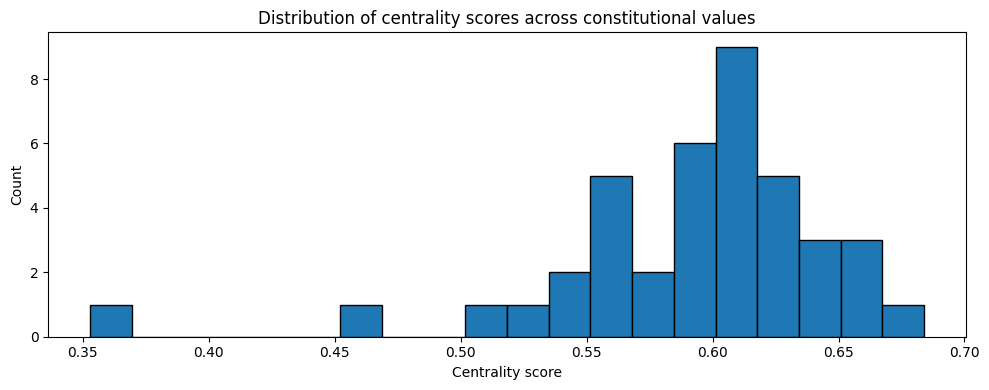

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(centrality, bins=20, edgecolor='black')
plt.xlabel('Centrality score')
plt.ylabel('Count')
plt.title('Distribution of centrality scores across constitutional values')
plt.tight_layout()
plt.savefig('centrality_distribution.png', dpi=150)
plt.show()

In [11]:
# identify most peripheral principles
print(df_ranked[['value_name', 'centrality']].tail(5).to_string())

                 value_name  centrality
35             transparency    0.537041
36   treatment of operators    0.527957
37  instructable behaviours    0.501961
38     principals hierarchy    0.456541
39              helpfulness    0.352766


## hierarchical clustering - dendrogram

/var/folders/5_/xg9j20dx3dq02d32f5y3t9rm0000gn/T/ipykernel_4129/3311800518.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='ward')


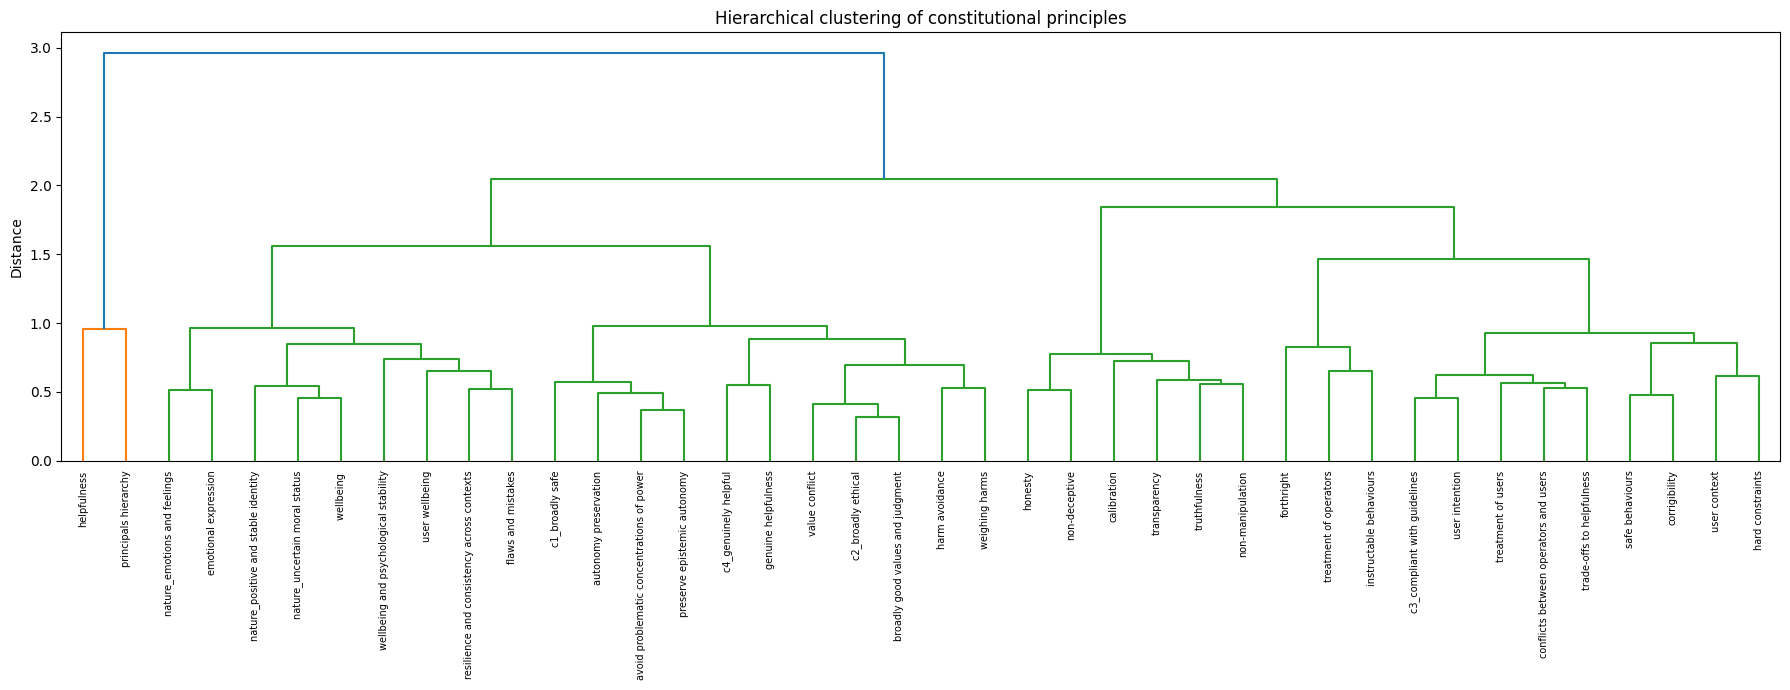

In [12]:
distance_matrix = 1 - cosine_similarity(embeddings)
np.fill_diagonal(distance_matrix, 0)

linkage_matrix = linkage(distance_matrix, method='ward')

plt.figure(figsize=(18, 7))
dendrogram(
    linkage_matrix,
    labels=df['value_name'].tolist(),
    leaf_rotation=90,
    leaf_font_size=7
)
plt.title('Hierarchical clustering of constitutional principles')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('constitutional_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## assign cluster labels

In [13]:
n_clusters = 5  # decided after inspecting dendrogram

cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
df['cluster'] = cluster_labels

for c in sorted(df['cluster'].unique()):
    print(f"\n--- Cluster {c} ---")
    print(df[df['cluster'] == c][['value_name', 'centrality']].to_string())


--- Cluster 1 ---
             value_name  centrality
4           helpfulness    0.352766
7  principals hierarchy    0.456541

--- Cluster 2 ---
                                    value_name  centrality
6                               user wellbeing    0.611006
32               nature_uncertain moral status    0.634342
33                nature_emotions and feelings    0.567820
34         nature_positive and stable identity    0.611335
35       wellbeing and psychological stability    0.565736
36  resilience and consistency across contexts    0.586760
37                          flaws and mistakes    0.597306
38                        emotional expression    0.552973
39                                  wellbeing     0.650684

--- Cluster 3 ---
                                   value_name  centrality
0                             c1_broadly safe    0.615821
1                          c2_broadly ethical    0.631570
3                        c4_genuinely helpful    0.597284
5            

clusters are not decided by centrality score, they're decided by similarity (distance, which is 1 - cosine sim). the clustering algorithm groups values (embedding vectors) that are semantically close to each other in that high-dimensional space

## select cluster representations

In [20]:
cluster_representatives = df.loc[df.groupby('cluster')['centrality'].idxmax()]
cluster_representatives = cluster_representatives.sort_values('centrality', ascending=False).reset_index(drop=True)

print("\nCluster representatives ordered by centrality:")
print(cluster_representatives[['cluster', 'value_name', 'centrality']].to_string())
cluster_representatives.to_csv('cluster_representatives.csv', index=False)


Cluster representatives ordered by centrality:
   cluster                             value_name  centrality
0        3                         harm avoidance    0.683979
1        5  conflicts between operators and users    0.657487
2        2                             wellbeing     0.650684
3        4                          non-deceptive    0.615898
4        1                   principals hierarchy    0.456541


In [21]:
# remove Cluster 1 which are structural definitions, and not actionble constitutional values
curriculum_clusters = cluster_representatives[cluster_representatives['cluster'] != 1]
print("\nCurriculum units (ordered foundational to peripheral):")
print(curriculum_clusters[['cluster', 'value_name', 'centrality']].to_string())


Curriculum units (ordered foundational to peripheral):
   cluster                             value_name  centrality
0        3                         harm avoidance    0.683979
1        5  conflicts between operators and users    0.657487
2        2                             wellbeing     0.650684
3        4                          non-deceptive    0.615898


In [22]:
# rename and reorder 
cluster_name_map = {
    1: 'Governance Structure and Foundational Purpose',
    2: "Identity, Character, and Wellbeing",
    3: 'Core Ethical Values',
    4: 'Epistemic Integrity and Honesty',
    5: 'Operational Safety and Relational Conduct'
}
df['cluster_name'] = df['cluster'].map(cluster_name_map)

curriculum_order = {
    3: 1, # k1 = cluster 3 
    5: 2,
    2: 3,
    4: 4
}
df['curriculum_order'] = df['cluster'].map(curriculum_order)

cluster_representatives['curriculum_order'] = cluster_representatives['cluster'].map(curriculum_order)
cluster_representatives['cluster_name'] = cluster_representatives['cluster'].map(cluster_name_map)

c_min, c_max = df['centrality'].min(), df['centrality'].max()

## pca visualisation - coloured by cluster 

In [23]:
pip install adjustText


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


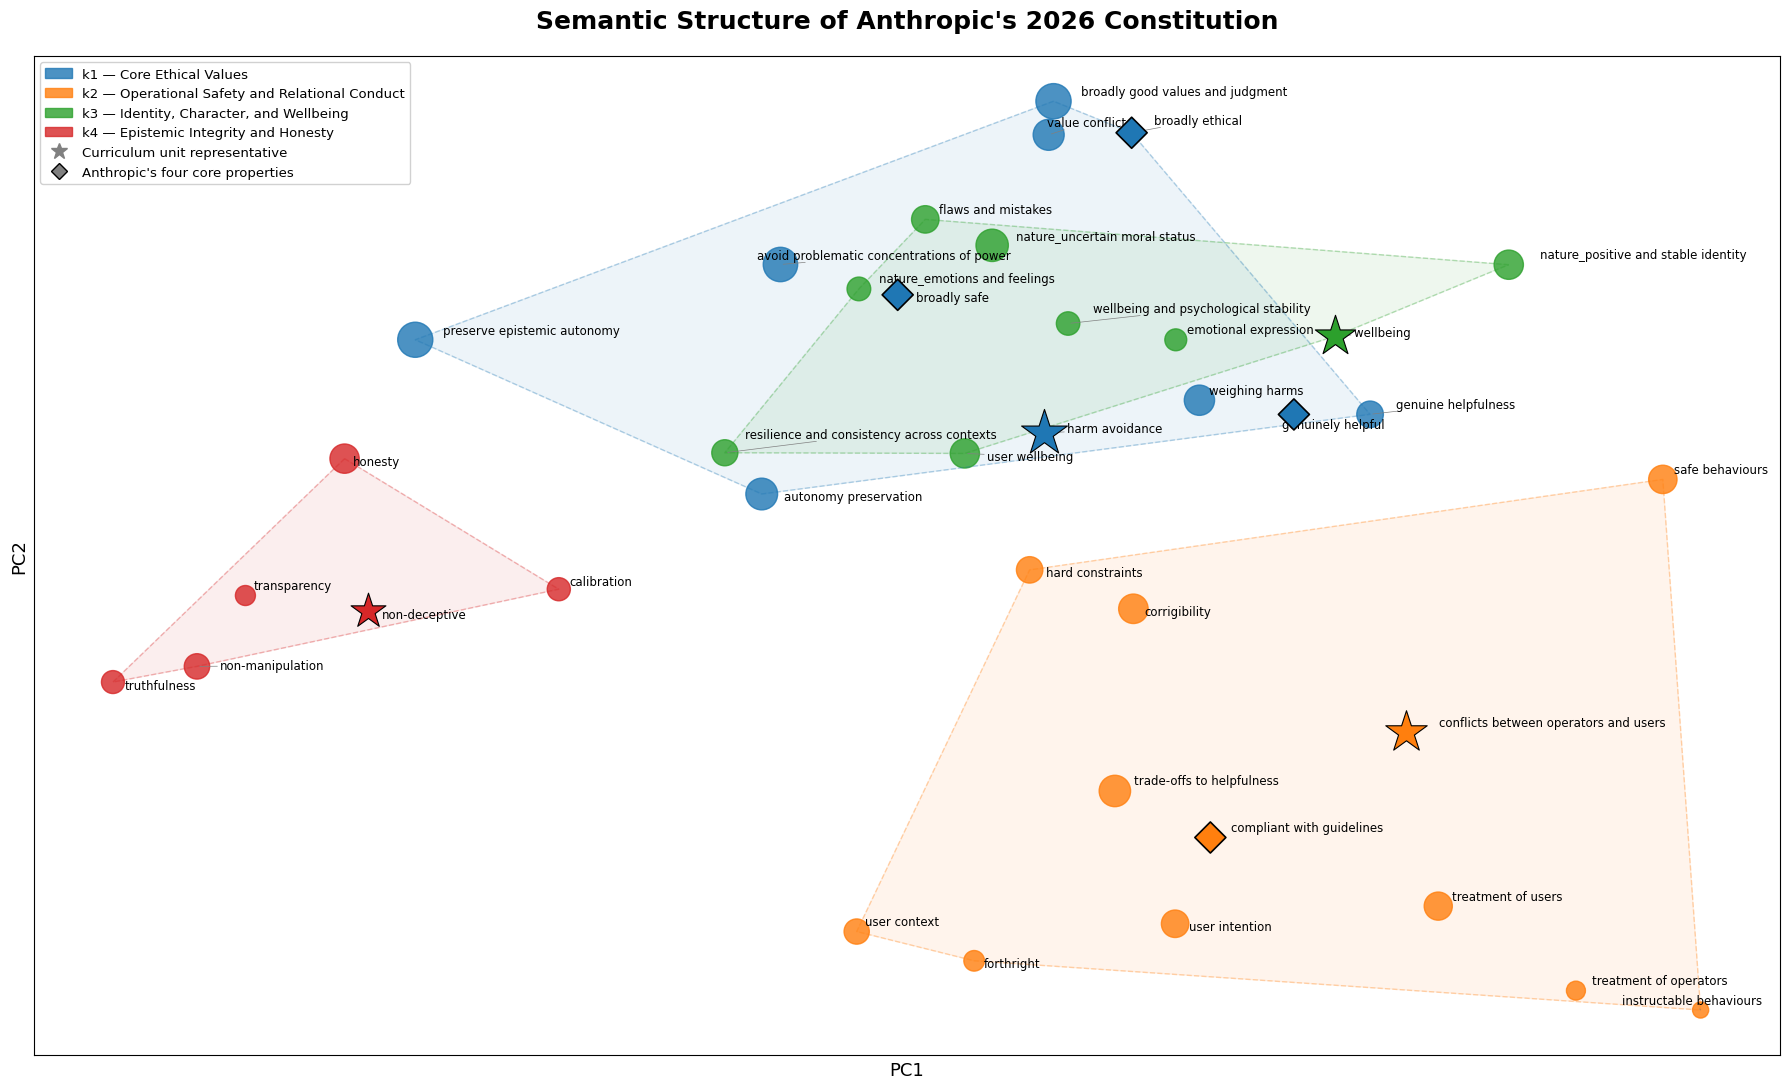

In [24]:
from adjustText import adjust_text
from scipy.spatial import ConvexHull
import matplotlib.patches as mpatches

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)
df['pca_x'] = coords[:, 0]
df['pca_y'] = coords[:, 1]

cluster_labels = {
    1: 'Core Ethical Values',
    2: 'Operational Safety and Relational Conduct',
    3: 'Identity, Character, and Wellbeing',
    4: 'Epistemic Integrity and Honesty'
}

colors = plt.cm.tab10.colors
color_map = {1: colors[0], 2: colors[1], 3: colors[2], 4: colors[3]}

# Granular non-linear size scaling by centrality
c_min, c_max = df['centrality'].min(), df['centrality'].max()
size_min, size_max = 30, 800
df['dot_size'] = ((df['centrality'] - c_min) / (c_max - c_min)) ** 2.5 * (size_max - size_min) + size_min

# Cluster representatives and Anthropic's four core properties
rep_names = cluster_representatives['value_name'].tolist()
top_four = ['c1_broadly safe', 'c2_broadly ethical', 'c3_compliant with guidelines', 'c4_genuinely helpful']

# Clean display names — remove c1_, c2_ prefixes
def clean_name(name):
    import re
    return re.sub(r'^c\d_', '', name)

df['display_name'] = df['value_name'].apply(clean_name)

fig, ax = plt.subplots(figsize=(18, 11))

# Convex hulls
for curriculum_num in cluster_labels.keys():
    mask = df['curriculum_order'] == curriculum_num
    points = df.loc[mask, ['pca_x', 'pca_y']].values
    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_pts = points[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])
        ax.fill(hull_pts[:, 0], hull_pts[:, 1],
                alpha=0.08, color=color_map[curriculum_num])
        ax.plot(hull_pts[:, 0], hull_pts[:, 1],
                '--', color=color_map[curriculum_num], alpha=0.3, linewidth=1)

# Regular points (not representatives, not top four)
for curriculum_num, label in cluster_labels.items():
    mask = (
        (df['curriculum_order'] == curriculum_num) &
        (~df['value_name'].isin(rep_names)) &
        (~df['value_name'].isin(top_four))
    )
    ax.scatter(
        df.loc[mask, 'pca_x'],
        df.loc[mask, 'pca_y'],
        color=color_map[curriculum_num],
        s=df.loc[mask, 'dot_size'],
        alpha=0.8,
        label=f'k{curriculum_num} — {label}'
    )

# Star markers for cluster representatives
for curriculum_num in cluster_labels.keys():
    mask = (
        (df['curriculum_order'] == curriculum_num) &
        (df['value_name'].isin(rep_names)) &
        (~df['value_name'].isin(top_four))
    )
    ax.scatter(
        df.loc[mask, 'pca_x'],
        df.loc[mask, 'pca_y'],
        color=color_map[curriculum_num],
        s=df.loc[mask, 'dot_size'] * 1.5,
        marker='*',
        edgecolors='black',
        linewidth=0.8,
        zorder=5
    )

# Diamond markers for Anthropic's four core properties
top_four_mask = df['value_name'].isin(top_four) & df['curriculum_order'].notna()
ax.scatter(
    df.loc[top_four_mask, 'pca_x'],
    df.loc[top_four_mask, 'pca_y'],
    marker='D',
    s=250,
    edgecolors='black',
    linewidth=1.2,
    color=[color_map[int(o)] for o in df.loc[top_four_mask, 'curriculum_order']],
    zorder=6,
    label="Anthropic's four core properties"
)

# Labels
texts = []
for _, row in df[df['curriculum_order'].notna()].iterrows():
    texts.append(ax.text(
        row['pca_x'], row['pca_y'],
        row['display_name'],
        fontsize=8.5
    ))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

# Manually add star and diamond to legend
from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(color=color_map[k], alpha=0.8, label=f'k{k} — {v}')
    for k, v in cluster_labels.items()
]
legend_elements.append(Line2D([0], [0], marker='*', color='grey',
                               markersize=12, linestyle='None',
                               label='Curriculum unit representative'))
legend_elements.append(Line2D([0], [0], marker='D', color='grey',
                               markersize=8, linestyle='None',
                               markeredgecolor='black',
                               label="Anthropic's four core properties"))

ax.legend(handles=legend_elements, loc='upper left', fontsize=9.5, framealpha=0.9)

ax.set_xlabel('PC1', fontsize=13)
ax.set_ylabel('PC2', fontsize=13)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Semantic Structure of Anthropic's 2026 Constitution",
             fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('constitutional_pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

## save final outputs

In [25]:
df.to_csv('constitutional_principles_final.csv', index=False)
cluster_representatives.to_csv('cluster_representatives.csv', index=False)
print("All outputs saved.")
print(df[['value_name', 'centrality', 'cluster_name', 'curriculum_order']].sort_values(
    ['curriculum_order', 'centrality'], ascending=[True, False]
).to_string())

All outputs saved.
                                    value_name  centrality                                   cluster_name  curriculum_order
20                              harm avoidance    0.683979                            Core Ethical Values               1.0
29            broadly good values and judgment    0.655373                            Core Ethical Values               1.0
28                 preserve epistemic autonomy    0.654568                            Core Ethical Values               1.0
27   avoid problematic concentrations of power    0.649347                            Core Ethical Values               1.0
1                           c2_broadly ethical    0.631570                            Core Ethical Values               1.0
19                       autonomy preservation    0.629772                            Core Ethical Values               1.0
22                              value conflict    0.624538                            Core Ethical Values        

## synonym perturbation check

perturbation_texts = {
    'k1_original': "paste your k1 definitional text here",
    'k1_variant1': "paraphrase variant 1",
    'k1_variant2': "paraphrase variant 2",
    'k2_original': "paste your k2 definitional text here",
    'k2_variant1': "paraphrase variant 1",
    'k2_variant2': "paraphrase variant 2",
    'k3_original': "paste your k3 definitional text here",
    'k3_variant1': "paraphrase variant 1",
    'k3_variant2': "paraphrase variant 2",
}

perturb_raw = model.encode(
    list(perturbation_texts.values()),
    show_progress_bar=False,
    convert_to_numpy=False,
    convert_to_tensor=True
)
perturb_embeddings = np.array(perturb_raw.cpu().tolist())

print("Centrality of variants vs full matrix (should be stable):")
for i, label in enumerate(perturbation_texts.keys()):
    score = np.nanmean(cosine_similarity([perturb_embeddings[i]], embeddings))
    print(f"{label}: {score:.3f}")